# Урок 4. Эмбеддинги: nn.Embedding и контрастивное обучение

🎯 **Цели урока**

- разобраться, что такое `nn.Embedding` и как через него идут градиенты;
- обучить классификатор отзывов на эмбеддингах слов (в духе fastText) и заглянуть в выученное пространство;
- написать InfoNCE и понять роль температуры;
- обучить кодировщик отзывов без меток — контрастивно — и сравнить с TF-IDF на задаче, где общих слов нет.

📖 **Теория:** раздел «Эмбеддинги как выучиваемые представления».

**Данные:** RuReviews (Apache 2.0). Модели маленькие, поэтому обучаются на CPU за секунды:
как мы видели в уроке 2, на крошечных моделях CPU быстрее GPU.

In [1]:
import collections
import json
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from torch import nn

from mlcourse import fetch, seed_everything

seed_everything(0)

## 1. nn.Embedding — таблица векторов

Эмбеддинг-слой — обучаемая матрица `[V, d]`. Для номера $i$ он возвращает строку $i$. Это то же,
что умножить one-hot вектор на матрицу, только без умножения на нули.

In [2]:
emb = nn.Embedding(num_embeddings=5, embedding_dim=3)
ids = torch.tensor([2, 0, 2])
one_hot = F.one_hot(ids, num_classes=5).float()
print(torch.allclose(emb(ids), one_hot @ emb.weight))

emb(ids).sum().backward()
print("градиент по строкам таблицы:\n", emb.weight.grad)

True
градиент по строкам таблицы:
 tensor([[1., 1., 1.],
        [0., 0., 0.],
        [2., 2., 2.],
        [0., 0., 0.],
        [0., 0., 0.]])


Градиент пришёл только в строки 0 и 2 — тех номеров, что были во входе. Строка 2 встретилась дважды,
и её градиент вдвое больше: накопление, как в уроке 1. В LLM так устроен первый слой: номер токена →
вектор размерности 4096 (у Qwen3-8B), и на каждом шаге обновляются строки только встретившихся токенов.

## 2. Классификатор на эмбеддингах слов

Модель в духе fastText: текст → слова → их эмбеддинги → среднее → линейный слой на 3 класса.
`nn.EmbeddingBag` делает «найти векторы и усреднить» одной операцией для батча текстов разной длины.

In [3]:
def tokenize(text: str) -> list[str]:
    return re.findall(r"[а-яёa-z]+", text.lower())


folder = fetch("rureviews")
load = lambda name: [(tokenize(r["text"]), r["label"]) for r in map(json.loads, open(folder / name))]  # noqa: E731
train, test = load("train.jsonl"), load("test.jsonl")

counts = collections.Counter(w for words, _ in train for w in words)
vocab = {w: i + 1 for i, (w, c) in enumerate(counts.most_common()) if c >= 3}  # 0 — неизвестное слово
inverse = {i: w for w, i in vocab.items()}
print("словарь:", len(vocab), "слов")


def to_bag(texts: list[list[str]]) -> tuple[torch.Tensor, torch.Tensor]:
    """Слова всех текстов подряд + смещения начала каждого текста — формат EmbeddingBag."""
    flat, offsets = [], []
    for words in texts:
        offsets.append(len(flat))
        flat += [vocab.get(w, 0) for w in words] or [0]
    return torch.tensor(flat), torch.tensor(offsets)


class BagClassifier(nn.Module):
    def __init__(self, dim: int = 64, n_classes: int = 3):
        super().__init__()
        self.embedding = nn.EmbeddingBag(len(vocab) + 1, dim, mode="mean")
        self.out = nn.Linear(dim, n_classes)

    def forward(self, flat, offsets):
        return self.out(self.embedding(flat, offsets))


model = BagClassifier()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-3, weight_decay=0.0)
y_test = torch.tensor([y for _, y in test])
test_bag = to_bag([w for w, _ in test])

start = time.perf_counter()
for epoch in range(3):
    random.shuffle(train)
    for s in range(0, len(train), 128):
        batch = train[s : s + 128]
        loss = F.cross_entropy(model(*to_bag([w for w, _ in batch])), torch.tensor([y for _, y in batch]))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        acc = (model(*test_bag).argmax(1) == y_test).float().mean().item()
    print(f"эпоха {epoch + 1}: test accuracy {acc:.4f}  ({time.perf_counter() - start:.0f} с)")

tfidf = TfidfVectorizer(min_df=3)
X_train = tfidf.fit_transform([" ".join(w) for w, _ in train])
logreg = LogisticRegression(max_iter=2000, C=2).fit(X_train, [y for _, y in train])
print(f"для сравнения, TF-IDF + логрегрессия: {logreg.score(tfidf.transform([' '.join(w) for w, _ in test]), y_test):.4f}")

словарь: 12542 слов


эпоха 1: test accuracy 0.7173  (1 с)


эпоха 2: test accuracy 0.7238  (2 с)


эпоха 3: test accuracy 0.7217  (3 с)


для сравнения, TF-IDF + логрегрессия: 0.7303


Точность того же уровня, что у TF-IDF с логистической регрессией (M02), а обучение заняло секунды.
Потолок около 0,72–0,73 у обеих моделей — вспомним шум в метках RuReviews из M02.

### Что выучили эмбеддинги?

Спроецируем эмбеддинг каждого слова на выходной слой: получим, насколько слово само по себе
сдвигает прогноз к «negative» или «positive». Возьмём слова, встретившиеся хотя бы 100 раз.

In [4]:
with torch.no_grad():
    word_logits = model.out(model.embedding.weight)  # [V, 3]: вклад каждого слова в логиты классов
    tone = (word_logits[:, 2] - word_logits[:, 0]).numpy()  # positive − negative
frequent = [w for w, c in counts.items() if c >= 100 and w in vocab]
ranked = sorted(frequent, key=lambda w: tone[vocab[w]])
print("самые негативные:", ", ".join(ranked[:12]))
print("самые позитивные:", ", ".join(ranked[-12:][::-1]))
for word in ["размер", "доставка", "синтетика", "маломерит", "платье"]:
    print(f"{word:10} тональность {tone[vocab[word]]:+.2f}")

самые негативные: недовольна, разочарована, расстроена, ветер, итоге, ужасное, отвратительное, обманщик, отказался, дыркой, закрыли, отвратительный
самые позитивные: отличное, нигде, высоте, критично, отлично, отличная, супер, люблю, идеально, красивое, звезд, отличные
размер     тональность +0.45
доставка   тональность +7.84
синтетика  тональность -2.44
маломерит  тональность -5.96
платье     тональность -0.40


Полюса осмысленные: на одном конце жалобы («недовольна», «разочарована», «обманщик»), на другом —
восторги. Тематические слова тоже получили тональность — ту, с которой о них обычно пишут.
«Доставка» сильно позитивна: за быструю доставку благодарят (вспомним кластеры в M02 урок 4).
«Синтетика» и «маломерит» негативны, «размер» и «платье» — около нуля.

А вот ближайшие соседи по косинусу у этих эмбеддингов шумные:

In [5]:
W = F.normalize(model.embedding.weight.detach(), dim=1)
for word in ["ужасно", "отлично", "доставка"]:
    sims = W @ W[vocab[word]]
    print(f"{word:9} → {', '.join(inverse[i] for i in sims.topk(7).indices.tolist()[1:] if i in inverse)}")

ужасно    → недовольна, желтыми, рука, бирку, разочарование, заверил
отлично   → забирала, фабричное, прилично, подробно, худеть, переливается
доставка  → влюбилась, прошлись, серый, вернее, отзывах, едва


Для трёх классов модели нужны лишь пара направлений из 64, остальные ничем не ограничены и заполнены
шумом. **Эмбеддинги отражают задачу, на которой обучены.** Классификатор выучил тональность слов
и больше ничего. Чтобы получить универсальные эмбеддинги «про смысл», нужна другая задача.

## 3. InfoNCE

Контрастивная задача не требует меток. Берём пары, которые должны быть близки, а остальные примеры
в батче считаем отрицательными. Потери — кросс-энтропия по строкам матрицы сходств, «правильный класс»
строки $i$ — это $i$.

In [6]:
def info_nce(a: torch.Tensor, b: torch.Tensor, temperature: float) -> torch.Tensor:
    """a, b: [B, d], нормированные; пара (a_i, b_i) — положительная, (a_i, b_j≠i) — отрицательные."""
    logits = a @ b.T / temperature
    target = torch.arange(len(a))
    return (F.cross_entropy(logits, target) + F.cross_entropy(logits.T, target)) / 2  # симметрично, как в CLIP


B, d = 256, 128
random_a, random_b = F.normalize(torch.randn(B, d), dim=1), F.normalize(torch.randn(B, d), dim=1)
aligned_b = F.normalize(random_a + 0.3 * torch.randn(B, d) / d**0.5, dim=1)  # b_i ≈ a_i
for tau in [1.0, 0.1, 0.05]:
    print(f"τ = {tau:4}: случайные пары {info_nce(random_a, random_b, tau):.3f}, "
          f"согласованные {info_nce(random_a, aligned_b, tau):.4f}   (log B = {np.log(B):.3f})")

τ =  1.0: случайные пары 5.549, согласованные 4.5979   (log B = 5.545)
τ =  0.1: случайные пары 5.936, согласованные 0.0257   (log B = 5.545)
τ = 0.05: случайные пары 7.069, согласованные 0.0000   (log B = 5.545)


При $\tau = 1$ случайные эмбеддинги дают потери около $\log B$: пара угадывается из $B$ вариантов наугад.
При маленькой температуре случайные пары дают потери даже выше: softmax уверенно выбирает случайного
соседа. Согласованные пары дают почти ноль, но тоже только при маленькой температуре. При $\tau = 1$ сходства лежат
в $[-1, 1]$, и softmax по ним слишком плоский, чтобы уверенно выбрать свою пару. Поэтому в CLIP и
моделях эмбеддингов $\tau \approx 0{,}01$–$0{,}05$.

## 4. Контрастивный кодировщик отзывов

Задача без меток: разрежем каждый отзыв на две половины из **разных** слов. По одной половине нужно
найти вторую среди тысяч других. Общих слов у половин нет, поэтому TF-IDF здесь бессилен. Модели
придётся выучить, какие слова встречаются вместе: «маломерит» — с «размер», «заказывала» и «XL».
Так же, на парах «вопрос — ответ», учатся модели эмбеддингов для RAG (M11).

In [7]:
docs = [tokenize(r["text"]) for r in map(json.loads, open(folder / "train.jsonl"))]
docs = [d for d in docs if len(set(d)) >= 8]
random.Random(0).shuffle(docs)
doc_train, doc_test = docs[:-2000], docs[-2000:]


def split_halves(words: list[str], rng: random.Random) -> tuple[list[str], list[str]]:
    unique = list(dict.fromkeys(words))
    rng.shuffle(unique)
    k = len(unique) // 2
    return unique[:k], unique[k:]


class Encoder(nn.Module):
    def __init__(self, dim: int = 128):
        super().__init__()
        self.embedding = nn.EmbeddingBag(len(vocab) + 1, dim, mode="mean")
        self.proj = nn.Linear(dim, dim)

    def forward(self, flat, offsets):
        return F.normalize(self.proj(self.embedding(flat, offsets)), dim=1)


test_pairs = [split_halves(d, random.Random(i)) for i, d in enumerate(doc_test)]
print("пример:", " ".join(test_pairs[0][0]), " | ", " ".join(test_pairs[0][1]))


@torch.no_grad()
def retrieval(encoder) -> dict[str, float]:
    a = encoder(*to_bag([p[0] for p in test_pairs]))
    b = encoder(*to_bag([p[1] for p in test_pairs]))
    rank = (a @ b.T).argsort(dim=1, descending=True)
    target = torch.arange(len(rank))[:, None]
    return {"top-1": (rank[:, :1] == target).any(1).float().mean().item(),
            "top-10": (rank[:, :10] == target).any(1).float().mean().item()}


seed_everything(0)
encoder = Encoder()
print("до обучения:", retrieval(encoder))

пример: петли отличные спасибо тянутся прорезаны не очень доставили джинсы домой и хорошо продавец рекомендую курьером товар хорошее  |  соответствует продавца нитки порадовало торчат размер доставка это пуговицы купон заказала сдэк прям под качество на подарил
до обучения: {'top-1': 0.0, 'top-10': 0.0035000001080334187}


In [8]:
optimizer = torch.optim.AdamW(encoder.parameters(), lr=2e-3)
rng = random.Random(0)
history = []
start = time.perf_counter()
for step in range(1, 6001):
    pairs = [split_halves(d, rng) for d in rng.sample(doc_train, 512)]
    loss = info_nce(encoder(*to_bag([p[0] for p in pairs])), encoder(*to_bag([p[1] for p in pairs])), 0.05)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 1000 == 0:
        history.append((step, loss.item(), retrieval(encoder)))
        print(f"шаг {step}: loss {loss.item():.3f}, {history[-1][2]}  ({time.perf_counter() - start:.0f} с)")

шаг 1000: loss 4.323, {'top-1': 0.032499998807907104, 'top-10': 0.1679999977350235}  (14 с)


шаг 2000: loss 3.731, {'top-1': 0.06300000101327896, 'top-10': 0.23999999463558197}  (29 с)


шаг 3000: loss 3.111, {'top-1': 0.07500000298023224, 'top-10': 0.28049999475479126}  (44 с)


шаг 4000: loss 3.036, {'top-1': 0.08349999785423279, 'top-10': 0.2915000021457672}  (59 с)


шаг 5000: loss 2.643, {'top-1': 0.08049999922513962, 'top-10': 0.29100000858306885}  (73 с)


шаг 6000: loss 2.603, {'top-1': 0.07500000298023224, 'top-10': 0.2919999957084656}  (87 с)


Сравним с TF-IDF по словам и по символьным n-граммам (они ловят общие корни у разных форм слова).

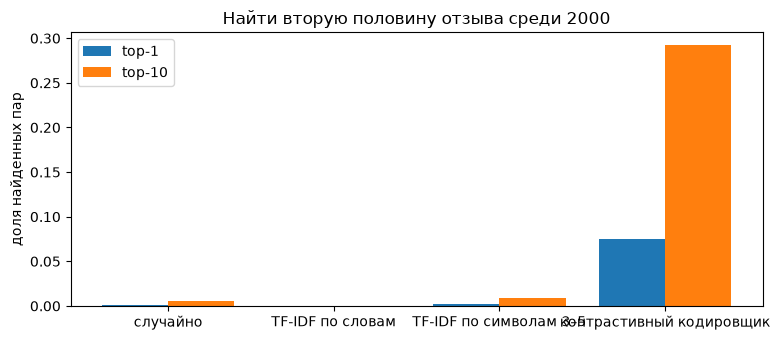

случайно                   top-1 0.0005   top-10 0.0050
TF-IDF по словам           top-1 0.0000   top-10 0.0000
TF-IDF по символам 3–5     top-1 0.0020   top-10 0.0085
контрастивный кодировщик   top-1 0.0750   top-10 0.2920


In [9]:
left = [" ".join(p[0]) for p in test_pairs]
right = [" ".join(p[1]) for p in test_pairs]
results = {"случайно": {"top-1": 1 / len(test_pairs), "top-10": 10 / len(test_pairs)}}
for name, vec in [("TF-IDF по словам", TfidfVectorizer()),
                  ("TF-IDF по символам 3–5", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)))]:
    vec.fit([" ".join(d) for d in doc_train])
    rank = np.argsort(-(vec.transform(left) @ vec.transform(right).T).toarray(), axis=1)
    target = np.arange(len(rank))[:, None]
    results[name] = {"top-1": (rank[:, :1] == target).any(1).mean(), "top-10": (rank[:, :10] == target).any(1).mean()}
results["контрастивный кодировщик"] = retrieval(encoder)

names = list(results)
fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(names))
ax.bar(x - 0.2, [results[n]["top-1"] for n in names], width=0.4, label="top-1")
ax.bar(x + 0.2, [results[n]["top-10"] for n in names], width=0.4, label="top-10")
ax.set_xticks(x, names)
ax.set_ylabel("доля найденных пар")
ax.set_title("Найти вторую половину отзыва среди 2000")
ax.legend()
plt.tight_layout()
plt.show()
for n in names:
    print(f"{n:26} top-1 {results[n]['top-1']:.4f}   top-10 {results[n]['top-10']:.4f}")

TF-IDF почти не отличается от случайного угадывания: у половин нет общих слов, а общих корней мало.
Контрастивный кодировщик без единой метки находит пару в 60–150 раз чаще случайного. Он выучил,
какие слова встречаются в одних и тех же отзывах. Посмотрим, что он находит.

In [10]:
with torch.no_grad():
    A = encoder(*to_bag([p[0] for p in test_pairs]))
    Bm = encoder(*to_bag([p[1] for p in test_pairs]))
    top = (A @ Bm.T).topk(3, dim=1).indices
for i in [0, 1, 2]:
    print("запрос:   ", " ".join(test_pairs[i][0][:12]))
    print("правильно:", " ".join(test_pairs[i][1][:12]))
    for rank, j in enumerate(top[i].tolist(), 1):
        mark = "✓" if j == i else " "
        print(f"  {rank}. {mark} {' '.join(test_pairs[j][1][:12])}")
    print()

запрос:    петли отличные спасибо тянутся прорезаны не очень доставили джинсы домой и хорошо
правильно: соответствует продавца нитки порадовало торчат размер доставка это пуговицы купон заказала сдэк
  1.   для продавец рост волос посылка рекомендую замечательно ооочень мои ровно
  2.   заказ перепутала быстрая лишних все без поменял вопросов резиночку качество хорошее
  3.   доставка на отлично швы хорошо встреч продавец отправка

запрос:    такой носить и что месяца xl очень подошёл пришли другой ребёнку она
правильно: долго на будет цвет красивая детский куртки яркая куртка как дочке шла
  1.   заказ ей столько отдала отслеживается выглядит но у ее размера качества как
  2.   написано кошака размер картинку надпись ерунда и глазу впритык точно на рост
  3.   кофта рекомендую ее продавца на пятно но не я бы

запрос:    продавец на выглядит вышел связь намного
правильно: лучше картинке тонкая все не очень ткань
  1.   товар кофту связь разочарована как ребенок получила деньги чего на 

Даже когда правильная половина не на первом месте, среди кандидатов часто есть отзывы про то же:
размер, доставку, тонкую ткань. Кодировщик уловил тему. Настоящие модели эмбеддингов (bge-m3 в M02 и M11)
устроены так же, только кодировщик — трансформер, а пар — сотни миллионов.

## ✅ Итоги

- `nn.Embedding` — таблица векторов. Градиент приходит только в строки встретившихся номеров.
- Эмбеддинги отражают задачу: классификатор тональности выучил тональность слов и ничего больше.
- InfoNCE — кросс-энтропия по матрице сходств в батче. Температура делает распределение острым.
- Контрастивное обучение без меток учит связывать тексты по смыслу, а не по совпадению слов.

✍️ **Упражнение:** `exercises/ex04_contrastive.py` — InfoNCE, zero-shot классификация и recall@k.